#Predicting Diabetes with Logistic Regression
### A Beginner-Friendly, End-to-End Machine Learning Project

---

## 1. Introduction and Problem Statement

**Background**

Diabetes is a chronic disease that affects how the body turns food into energy. Early detection
allows patients to change their lifestyle or start treatment before serious complications
(heart disease, kidney damage, vision loss) develop. Doctors currently rely on blood tests, but
a quick **screening model** built from routinely-collected health measurements can help flag
high-risk patients for further testing.

**Dataset**

We use the classic **Pima Indians Diabetes Dataset**, which contains diagnostic measurements
for **female patients of Pima Indian heritage, aged 21 and above**. Each row is one patient,
and the columns are:

| Column | Meaning |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skin fold thickness (mm) |
| `Insulin` | 2-Hour serum insulin (mu U/ml) |
| `BMI` | Body Mass Index (weight in kg / (height in m)^2) |
| `DiabetesPedigreeFunction` | A score estimating diabetes likelihood based on family history |
| `Age` | Age in years |
| `Outcome` | **Target** — 1 = has diabetes, 0 = does not have diabetes |

**Problem Statement**

> Given a patient's diagnostic measurements, predict whether the patient has diabetes
> (`Outcome = 1`) or not (`Outcome = 0`).

This is a **binary classification** problem, which makes **Logistic Regression** a natural,
interpretable first model to try.

**Project Roadmap**

1. Load and understand the data
2. Clean the data (handle missing/invalid values, duplicates)
3. Explore the data visually (EDA)
4. Prepare features (`X`) and target (`y`)
5. Split into train/test sets
6. Scale features
7. Learn the theory behind Logistic Regression
8. Train the model
9. Make predictions and interpret coefficients
10. Predict on a brand-new patient
11. Save/load the model with `joblib`
12. Sketch a simple deployment workflow
13. Conclude, then practice with interview questions and exercises


## 2. Import Required Libraries

We import everything we need up front:
- **pandas / numpy** → data loading and manipulation
- **matplotlib / seaborn** → data visualization
- **scikit-learn** → preprocessing, model training, evaluation
- **joblib** → saving/loading the trained model


In [ ]:
from sklearn.metrics import (
    accuracy_score,       # overall percentage of correct predictions
    confusion_matrix,     # table of TP/FP/TN/FN counts
    classification_report,# precision, recall, f1-score per class
    roc_auc_score,        # area under the ROC curve
    roc_curve,            # points needed to plot the ROC curve
    precision_score,      # of predicted positives, how many were correct
    recall_score,         # of actual positives, how many were found
    f1_score               # harmonic mean of precision and recall
)

In [1]:
# pandas: used to load and manipulate tabular data (DataFrames)
import pandas as pd
# numpy: used for numerical operations (arrays, NaN handling, math functions)
import numpy as np
# matplotlib.pyplot: the core plotting library
import matplotlib.pyplot as plt
# seaborn: a statistical plotting library built on top of matplotlib (nicer default styles)
import seaborn as sns
# train_test_split: splits data into training and testing subsets
from sklearn.model_selection import train_test_split
# StandardScaler: standardizes features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler
# LogisticRegression: the classification algorithm we will use
from sklearn.linear_model import LogisticRegression
# Metrics we will use to evaluate the trained model
# joblib: used to save (serialize) and load the trained model + scaler to/from disk
import joblib
# Make plots render inside the notebook (harmless if already default in modern Jupyter)
%matplotlib inline
# Set a consistent, pleasant plot style for all charts in this notebook
sns.set_style("whitegrid")
# Set a fixed random seed constant we will reuse everywhere for reproducibility
RANDOM_STATE = 42
print("All libraries imported successfully.")  # confirms the cell ran without errors

All libraries imported successfully.


## 3. Load the Dataset

We load `diabetes.csv` into a pandas DataFrame. Make sure the CSV file is in the same
folder as this notebook (or update the path below).


In [2]:
# Read the CSV file into a pandas DataFrame called 'df'
df = pd.read_csv(r"C:\Users\DELL\Downloads\diabetes.csv")

# Display a confirmation message along with the shape of the loaded data
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 773 rows and 9 columns.


## 4. Data Understanding

Before touching the data, we need to understand its structure: what columns exist,
what type of data each column holds, whether there are obvious problems, and what the
basic statistics look like.


In [3]:
# .head() shows the first 5 rows so we can visually inspect the data
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,146,76,20,283,42.9,0.078,46,1
1,3,98,82,0,14,25.9,0.140,27,0
2,9,102,60,39,0,37.5,0.792,39,1
3,9,199,66,33,0,32.7,1.485,31,1
4,3,122,71,22,0,26.5,0.487,31,0


In [4]:
# .info() shows column names, non-null counts, and data types (dtype)
# Useful for spotting missing values and incorrect data types at a glance
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               773 non-null    int64  
 1   Glucose                   773 non-null    int64  
 2   BloodPressure             773 non-null    int64  
 3   SkinThickness             773 non-null    int64  
 4   Insulin                   773 non-null    int64  
 5   BMI                       773 non-null    float64
 6   DiabetesPedigreeFunction  773 non-null    float64
 7   Age                       773 non-null    int64  
 8   Outcome                   773 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.5 KB


In [5]:
# .describe() shows summary statistics (count, mean, std, min, quartiles, max)
# for every numeric column — great for spotting suspicious values (e.g. a min of 0
# for Glucose or BMI, which is medically impossible)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,3.796895,120.900388,65.945666,20.640362,75.517464,31.690039,0.478442,33.513583,0.350582
std,2.969428,32.266485,22.828424,16.136401,100.442293,8.457090,0.311378,9.648694,0.477461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,54.000000,0.000000,0.000000,26.600000,0.233000,26.000000,0.000000
50%,3.000000,120.000000,68.000000,23.000000,14.000000,31.800000,0.452000,32.000000,0.000000
75%,6.000000,139.000000,81.000000,33.000000,146.000000,37.000000,0.686000,39.000000,1.000000
max,15.000000,199.000000,122.000000,63.000000,492.000000,60.500000,1.574000,81.000000,1.000000


In [6]:
# .shape returns a tuple of (number_of_rows, number_of_columns)
print("Shape of the dataset (rows, columns):", df.shape)

Shape of the dataset (rows, columns): (773, 9)


In [7]:
# .columns lists all column names in the DataFrame
print("Column names:", list(df.columns))

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


**Insight:** Looking at `describe()`, columns such as `Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin`, and `BMI` have a **minimum value of 0**. Biologically, a living
patient cannot have zero glucose, zero blood pressure, or zero BMI — these zeros are almost
certainly **placeholders for missing data**, not real measurements. We will fix this in the
next section.


## 5. Data Cleaning

We will:
1. Check for (and count) missing values
2. Check for (and remove) duplicate rows
3. Replace biologically-invalid zeros in specific columns with `NaN`
4. Impute those `NaN`s using the **median** of each column (median is robust to outliers)


In [8]:
# .isnull().sum() counts missing (NaN) values in each column
print("Missing values per column BEFORE cleaning:")
print(df.isnull().sum())

Missing values per column BEFORE cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# .duplicated().sum() counts the number of fully duplicated rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Drop duplicate rows, keeping the first occurrence, and reset the index
df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 5
Shape after removing duplicates: (768, 9)


In [10]:
# These columns cannot legitimately be zero for a living patient,
# so a 0 here really means "value not recorded"
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0 with NaN (numpy's "Not a Number") in those specific columns only
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)

# Confirm how many NaNs now exist in each of those columns
print("Missing values after converting invalid zeros to NaN:")
print(df[cols_with_invalid_zeros].isnull().sum())

Missing values after converting invalid zeros to NaN:
Glucose            5
BloodPressure     34
SkinThickness    226
Insulin          374
BMI               10
dtype: int64


In [11]:
# Impute (fill in) each column's missing values with that column's own median.
# We loop through each affected column one at a time.
for col in cols_with_invalid_zeros:
    median_value = df[col].median()      # compute the median, ignoring NaNs
    df[col] = df[col].fillna(median_value)  # replace NaNs with the median
    print(f"Filled missing values in '{col}' with median = {median_value}")

# Final check: there should be 0 missing values left anywhere in the dataset
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

Filled missing values in 'Glucose' with median = 120.0
Filled missing values in 'BloodPressure' with median = 69.0
Filled missing values in 'SkinThickness' with median = 28.0
Filled missing values in 'Insulin' with median = 140.5
Filled missing values in 'BMI' with median = 31.9

Missing values AFTER cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Insight:** After cleaning, the dataset has **no missing values and no duplicate rows**.
Median imputation was chosen (instead of mean) because medical measurements like `Insulin`
often have skewed distributions with outliers, and the median is less affected by extreme
values than the mean.


## 6. Exploratory Data Analysis (EDA)

Now that the data is clean, we visualize it to understand patterns, distributions, and
relationships between features and the target (`Outcome`).


### 6.1 Class Balance (Countplot)

First, let's check how many patients have diabetes vs. do not — this tells us whether
our classes are balanced or imbalanced.


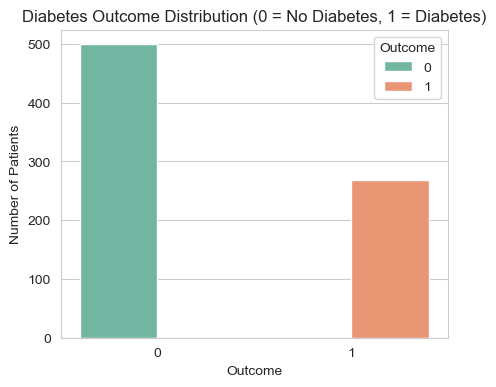

Outcome
0    499
1    269
Name: count, dtype: int64
Outcome
0    65.0
1    35.0
Name: proportion, dtype: float64 %


In [12]:
# Countplot shows the number of occurrences of each unique value in 'Outcome'
plt.figure(figsize=(5, 4))                       # Set figure size

# Create the count plot
sns.countplot(x="Outcome", hue="Outcome", data=df, palette="Set2")

# Set the title and axis labels
plt.title("Diabetes Outcome Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

# Display the plot
plt.show()

# Print the exact counts and percentages
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True).round(3) * 100, "%")

**Insight:** The dataset is **moderately imbalanced** — there are noticeably more
non-diabetic patients than diabetic ones. This is common in medical datasets and means we
should look beyond plain accuracy (e.g. at precision/recall) when evaluating the model later.


### 6.2 Feature Distributions (Histograms)

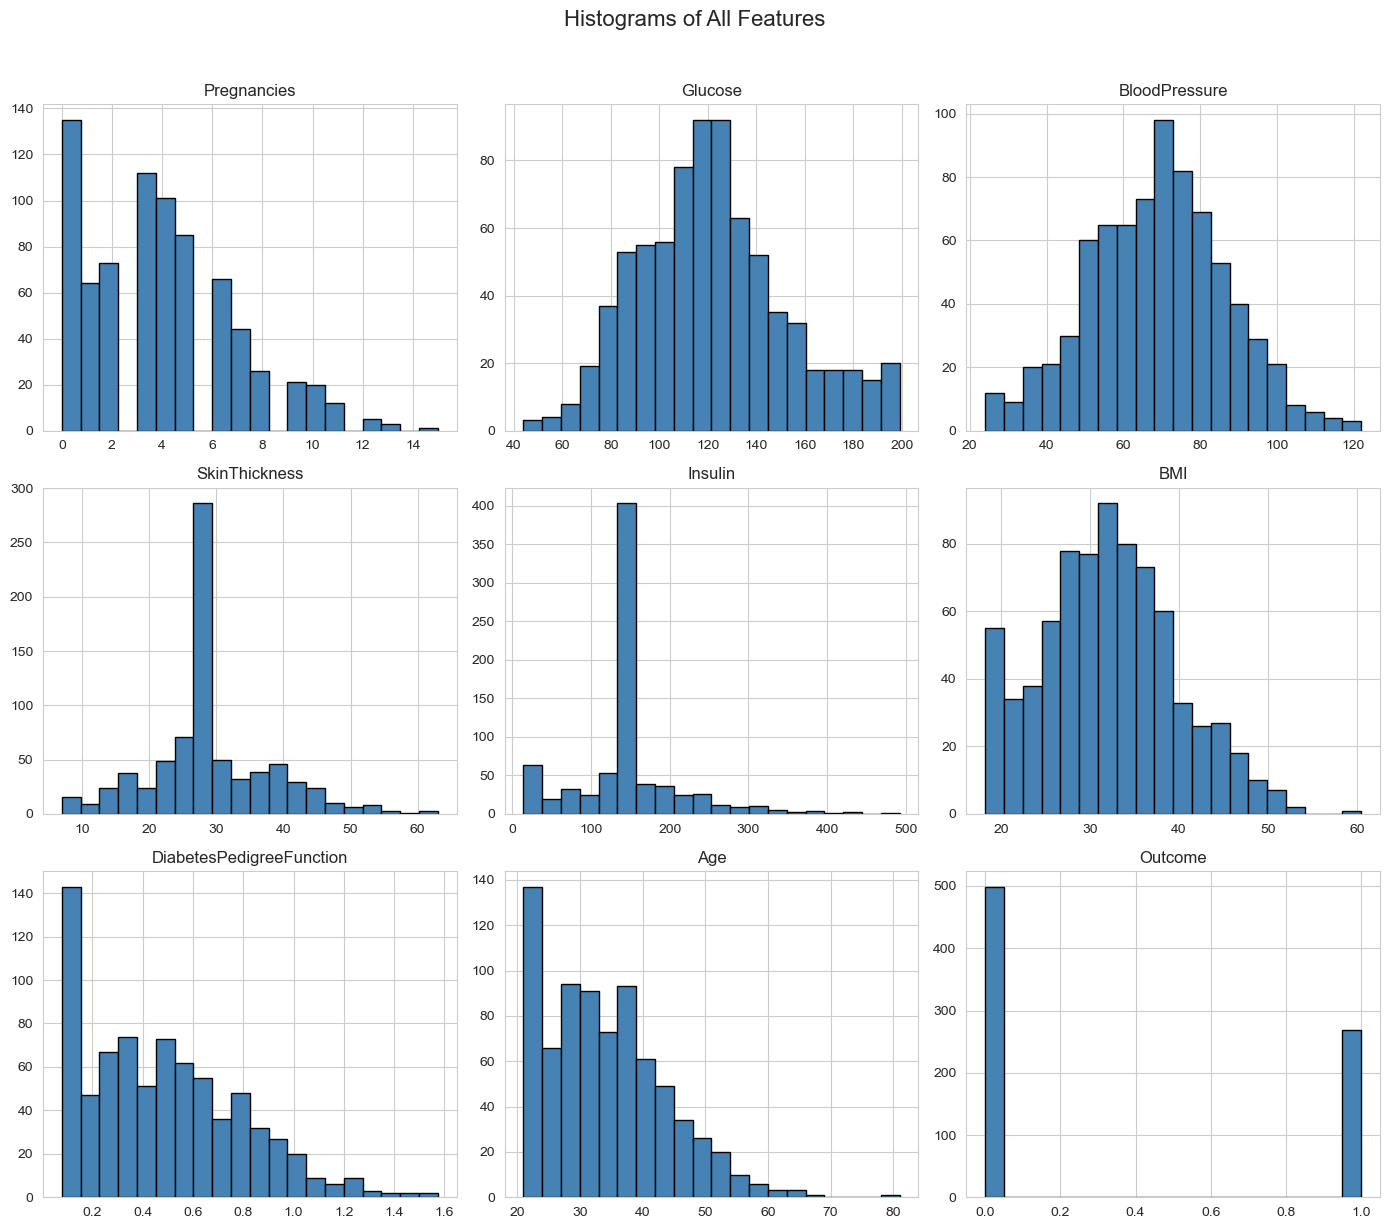

In [13]:
# .hist() plots a histogram for every numeric column in one figure
df.hist(figsize=(14, 12), bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Histograms of All Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** `Age` and `DiabetesPedigreeFunction` are right-skewed (most patients are
younger with a long tail of older patients). `Glucose` and `BMI` look closer to a normal
(bell-shaped) distribution after cleaning, which is what we would expect for these measurements.


### 6.3 Outlier Detection (Boxplots)

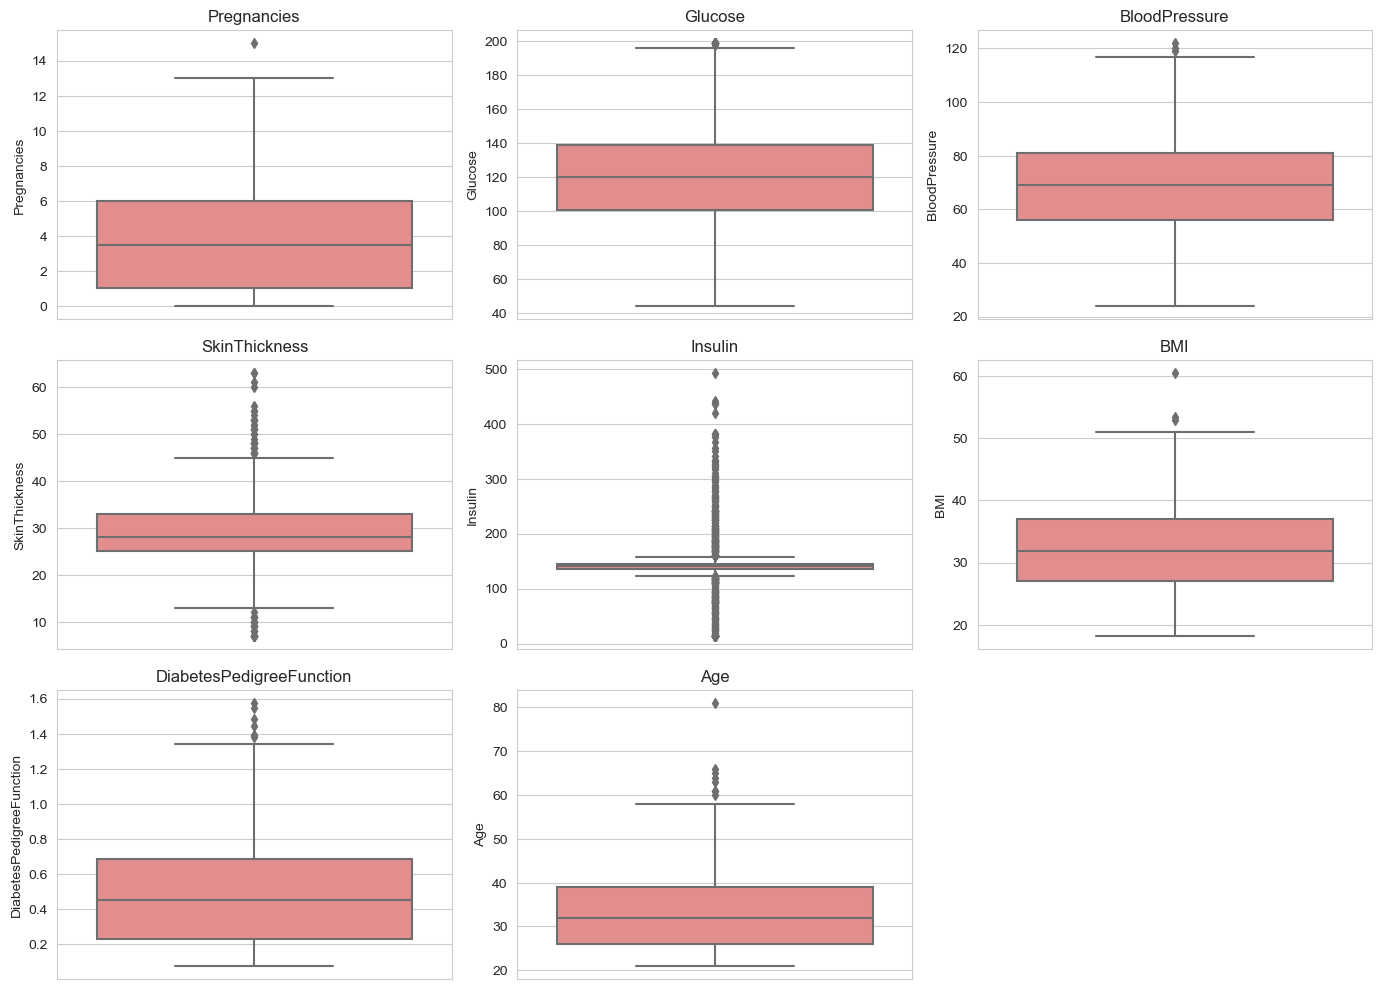

In [14]:
# Boxplots make it easy to spot outliers (points beyond the 'whiskers')
plt.figure(figsize=(14, 10))
feature_cols = df.columns[:-1]                    # every column except the target 'Outcome'

for i, col in enumerate(feature_cols):
    plt.subplot(3, 3, i + 1)                       # 3x3 grid of subplots
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(col)

plt.tight_layout()
plt.show()

**Insight:** `Insulin` and `SkinThickness` show the most outliers, which makes sense —
these were the columns with the most imputed (median-filled) values. `Pregnancies` also has a
long tail (a small number of patients with many pregnancies).


### 6.4 Relationships Between Features (Pairplot)

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

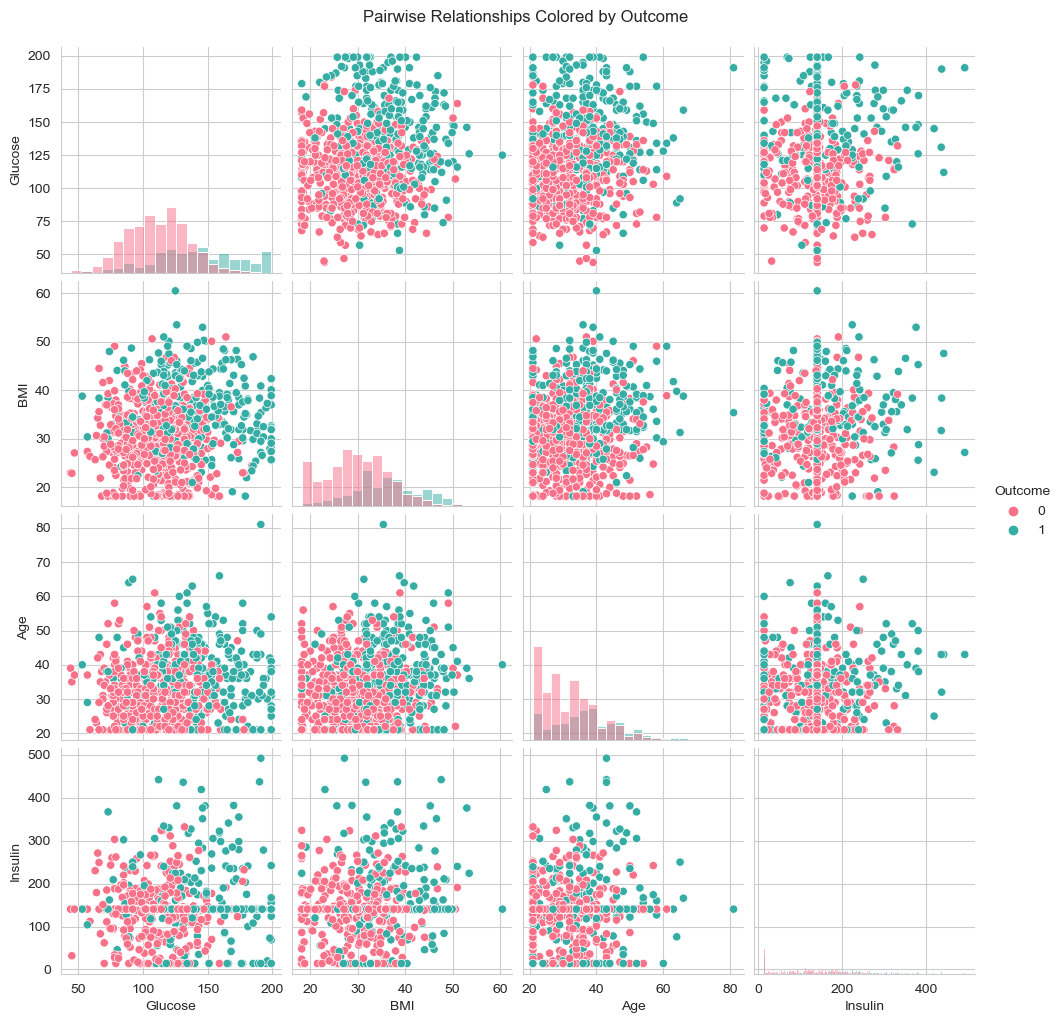

In [15]:
# Pairplot shows pairwise scatter plots between selected features, colored by Outcome.
# We use a subset of features (instead of all 8) to keep the plot readable and fast to render.
sns.pairplot(
    df,
    hue="Outcome",                                 # color points by diabetes outcome
    vars=["Glucose", "BMI", "Age", "Insulin"],      # features to compare
    palette="husl",
    diag_kind="hist"                                 # histogram on the diagonal
)
plt.suptitle("Pairwise Relationships Colored by Outcome", y=1.02)
plt.show()

**Insight:** Diabetic patients (`Outcome = 1`) tend to cluster at **higher Glucose**
values, which visually confirms that `Glucose` is likely to be a strong predictor.


### 6.5 Correlation Heatmap

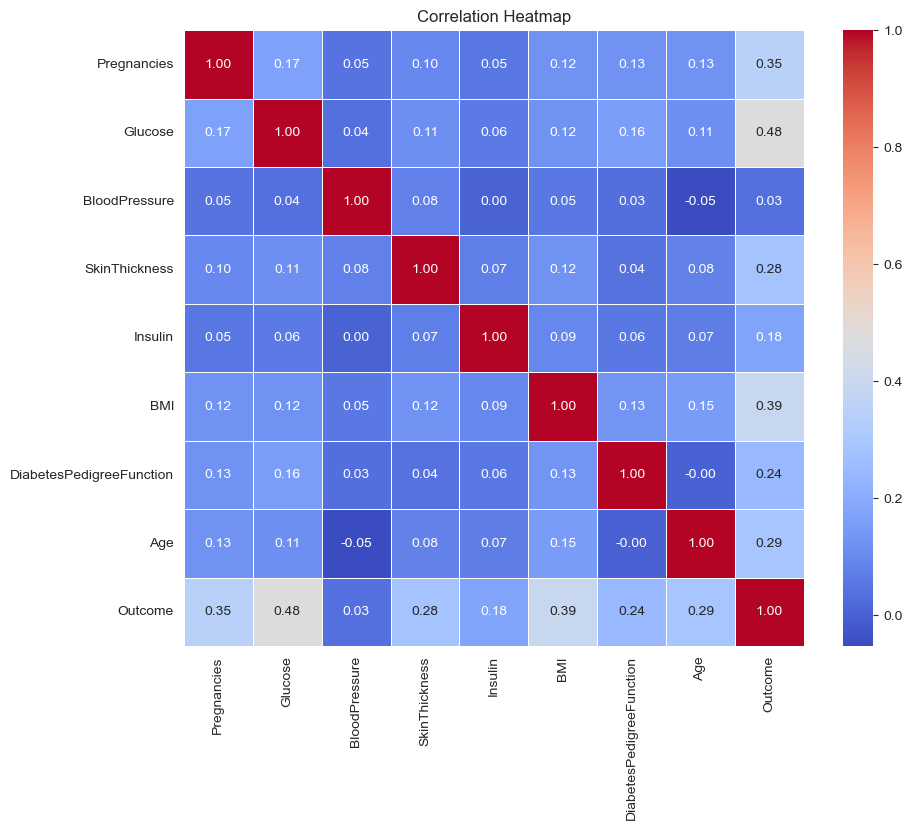

Correlation of each feature with Outcome (sorted):
Outcome                     1.000000
Glucose                     0.477537
BMI                         0.393359
Pregnancies                 0.345677
Age                         0.288570
SkinThickness               0.282430
DiabetesPedigreeFunction    0.244502
Insulin                     0.175572
BloodPressure               0.034096
Name: Outcome, dtype: float64


In [16]:
# Compute the pairwise correlation matrix between all numeric columns
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,          # write the correlation value inside each cell
    fmt=".2f",            # show 2 decimal places
    cmap="coolwarm",      # blue = negative correlation, red = positive correlation
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

# Show which features correlate most strongly with the target 'Outcome'
print("Correlation of each feature with Outcome (sorted):")
print(correlation_matrix["Outcome"].sort_values(ascending=False))

**Insight:** `Glucose` has the **strongest positive correlation** with `Outcome`,
followed by `BMI` and `Age`. `BloodPressure` has the weakest correlation with the target,
suggesting it may contribute the least predictive power.


## 7. Feature Selection

We separate the DataFrame into:
- **X** — the input features (everything except `Outcome`)
- **y** — the target variable (`Outcome`)

We use all 8 available features, since the correlation heatmap did not reveal any
feature that is completely useless, and Logistic Regression handles moderately weak
features reasonably well.


In [17]:
# X: drop the target column, keep every other column as a feature
X = df.drop("Outcome", axis=1)

# y: keep only the target column
y = df["Outcome"]

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeatures used:", list(X.columns))

Feature matrix X shape: (768, 8)
Target vector y shape: (768,)

Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 8. Train-Test Split

We split the data into a **training set** (used to fit the model) and a **test set**
(held back, used only to evaluate the model on unseen data). We use:
- `test_size=0.2` → 20% of the data reserved for testing
- `random_state=42` → makes the split reproducible every time we run this notebook
- `stratify=y` → preserves the same class balance (proportion of diabetic patients) in
  both the train and test sets, which matters because our classes are imbalanced


In [18]:
# Split X and y into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% of data goes to the test set
    random_state=42,        # fixed seed for reproducibility
    stratify=y               # keep the diabetic/non-diabetic ratio consistent in both sets
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


## 9. Feature Scaling using StandardScaler

Logistic Regression is a **distance/gradient-based** algorithm, so features on very
different scales (e.g. `Insulin` in the hundreds vs `DiabetesPedigreeFunction` under 3)
can bias training. `StandardScaler` transforms each feature to have **mean = 0** and
**standard deviation = 1**.

**Important:** we `fit` the scaler only on the **training data** (so it learns the mean/std
from training data only), then use that same fitted scaler to `transform` both the training
and test data. This avoids "data leakage" from the test set into training.


In [19]:
# Create a StandardScaler instance
scaler = StandardScaler()

# fit_transform: learn the mean/std from X_train, then scale X_train using them
X_train_scaled = scaler.fit_transform(X_train)

# transform only: scale X_test using the SAME mean/std learned from X_train
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print("Mean of each scaled training feature (should be ~0):")
print(np.round(X_train_scaled.mean(axis=0), 3))
print("\nStd of each scaled training feature (should be ~1):")
print(np.round(X_train_scaled.std(axis=0), 3))

Feature scaling complete.
Mean of each scaled training feature (should be ~0):
[-0. -0. -0.  0.  0. -0.  0.  0.]

Std of each scaled training feature (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]


## 10. Logistic Regression — Theory

### 10.1 Why not Linear Regression?

Linear Regression predicts a continuous number and can output any value from -∞ to +∞,
which doesn't make sense for a "yes/no" (diabetes / no diabetes) problem. We need a model
whose output can be interpreted as a **probability**, i.e. a number between 0 and 1.

### 10.2 The Sigmoid Function

Logistic Regression first computes a linear combination of the inputs, just like Linear
Regression:

$$ z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n $$

It then squashes `z` into the range (0, 1) using the **sigmoid (logistic) function**:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

- When `z` is very large (positive), `σ(z)` approaches **1**.
- When `z` is very negative, `σ(z)` approaches **0**.
- When `z = 0`, `σ(z) = 0.5`.

The output `σ(z)` is interpreted as **P(Outcome = 1 | features)** — the probability the
patient has diabetes.

### 10.3 The Decision Boundary

To turn a probability into a class label, we apply a **threshold** (commonly 0.5):

$$
\hat{y} =
\begin{cases}
1 & \text{if } \sigma(z) \geq 0.5 \\
0 & \text{if } \sigma(z) < 0.5
\end{cases}
$$

Geometrically, this threshold corresponds to a **decision boundary** — a straight line
(or hyperplane, in higher dimensions) that separates the "predict diabetes" region from
the "predict no diabetes" region in feature space.

### 10.4 How the Model Learns

The model finds the coefficients (`β₀, β₁, ..., βₙ`) that **minimize the log-loss**
(a.k.a. binary cross-entropy) between the predicted probabilities and the true labels,
typically using an iterative optimization algorithm (scikit-learn uses solvers like
`lbfgs` by default).


## 11. Train the Logistic Regression Model

We now fit a `LogisticRegression` model on the **scaled training data**. We set
`random_state=42` for reproducibility and increase `max_iter` so the optimizer has
enough iterations to converge.


In [20]:
# Create the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)

# Train (fit) the model on the scaled training features and training labels
model.fit(X_train_scaled, y_train)

print("Model training complete.")
print("Number of iterations run by the solver:", model.n_iter_[0])

Model training complete.
Number of iterations run by the solver: 9


## 12. Make Predictions

- `predict()` returns the **predicted class label** (0 or 1) for each test sample.
- `predict_proba()` returns the **predicted probability** of each class
  (column 0 = probability of "no diabetes", column 1 = probability of "diabetes").


In [21]:
# Predict class labels (0 or 1) for the test set
y_pred = model.predict(X_test_scaled)

# Predict class probabilities for the test set
y_proba = model.predict_proba(X_test_scaled)

# Show the first 10 predictions side-by-side with actual values and probabilities
results_preview = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "P(No Diabetes)": np.round(y_proba[:10, 0], 3),
    "P(Diabetes)": np.round(y_proba[:10, 1], 3)
})
print(results_preview)

   Actual  Predicted  P(No Diabetes)  P(Diabetes)
0       1          1           0.010        0.990
1       0          0           0.981        0.019
2       1          0           0.657        0.343
3       0          0           0.973        0.027
4       0          0           0.982        0.018
5       0          0           0.717        0.283
6       0          0           0.938        0.062
7       0          0           0.972        0.028
8       0          0           0.910        0.090
9       0          0           0.925        0.075


## 13. Interpret Model Coefficients

Each coefficient (`β`) tells us how a **one standard-deviation increase** in that
(scaled) feature changes the **log-odds** of having diabetes, holding other features
constant:
- A **positive** coefficient → increases the probability of diabetes.
- A **negative** coefficient → decreases the probability of diabetes.
- The **larger the magnitude**, the stronger the feature's influence.


                    Feature  Coefficient
0                   Glucose     1.274795
1                       BMI     0.819678
2               Pregnancies     0.812369
3                       Age     0.635815
4             SkinThickness     0.593730
5                   Insulin     0.465444
6  DiabetesPedigreeFunction     0.344151
7             BloodPressure    -0.029153


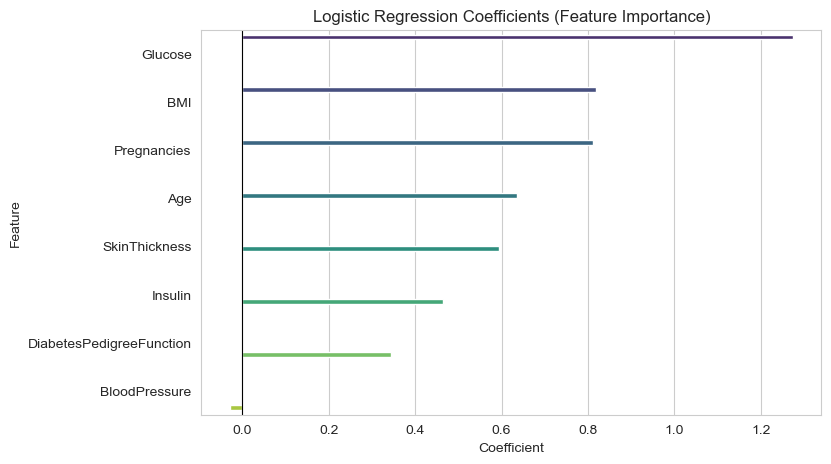


Intercept (beta_0): -1.0187


In [22]:
# Build a DataFrame pairing each feature with its learned coefficient
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False).reset_index(drop=True)

print(coef_df)

# Visualize the coefficients as a horizontal bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    hue="Feature",
    data=coef_df,
    palette="viridis"
)

plt.title("Logistic Regression Coefficients (Feature Importance)")
plt.axvline(x=0, color="black", linewidth=0.8)

# Remove the legend
plt.legend([], [], frameon=False)

plt.show()

# The intercept (bias term)
print(f"\nIntercept (beta_0): {model.intercept_[0]:.4f}")

**Insight:** `Glucose` typically emerges as the **strongest positive predictor** of
diabetes, aligning with medical knowledge (glucose tolerance tests are a core diagnostic
tool). `BMI`, `Pregnancies`, and `Age` also contribute positively. `BloodPressure` tends to
have the smallest (sometimes even slightly negative) coefficient, confirming what we saw
in the correlation heatmap.


## 14. Predict Diabetes for a New Patient

Let's simulate a doctor entering a new patient's measurements and getting an instant
prediction. Remember: any new data must go through the **same scaling** as the training
data before being fed to the model.


In [23]:
# Create a new patient's data as a DataFrame with the SAME column names/order as X
new_patient = pd.DataFrame({"Pregnancies": [2],"Glucose": [130],"BloodPressure": [70],
    "SkinThickness": [25],"Insulin": [100],"BMI": [28.5],"DiabetesPedigreeFunction": [0.35],
    "Age": [29]
})

print("New patient data:")
print(new_patient)

# Scale the new patient's data using the SAME scaler fitted on the training data
new_patient_scaled = scaler.transform(new_patient)

# Predict the class label (0 = no diabetes, 1 = diabetes)
new_prediction = model.predict(new_patient_scaled)

# Predict the class probabilities
new_probability = model.predict_proba(new_patient_scaled)

print(f"\nPredicted class: {new_prediction[0]} "
      f"({'Diabetes' if new_prediction[0] == 1 else 'No Diabetes'})")
print(f"Probability of No Diabetes: {new_probability[0][0]:.2%}")
print(f"Probability of Diabetes:    {new_probability[0][1]:.2%}")

New patient data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2      130             70             25      100  28.5   

   DiabetesPedigreeFunction  Age  
0                      0.35   29  

Predicted class: 0 (No Diabetes)
Probability of No Diabetes: 92.88%
Probability of Diabetes:    7.12%


In [27]:
model

LogisticRegression(max_iter=1000, random_state=42)

## 15. Save and Load the Model using joblib

In real projects, we train a model once and then **reuse** it many times without
retraining. `joblib` efficiently serializes (saves) Python objects — including
scikit-learn models — to disk. We must also save the `scaler`, since any future input
needs to be scaled the exact same way before prediction.


In [24]:
# Save the trained model to a file
joblib.dump(model, "logistic_regression_diabetes_model.pkl")

# Save the fitted scaler to a file (needed to preprocess future inputs identically)
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved to disk as:")
print(" - logistic_regression_diabetes_model.pkl")
print(" - scaler.pkl")

Model and scaler saved to disk as:
 - logistic_regression_diabetes_model.pkl
 - scaler.pkl


In [25]:
# Load the model back from disk
loaded_model = joblib.load("logistic_regression_diabetes_model.pkl")

# Load the scaler back from disk
loaded_scaler = joblib.load("scaler.pkl")

# Sanity check: use the LOADED model + scaler to predict on the same new_patient data
loaded_prediction = loaded_model.predict(loaded_scaler.transform(new_patient))

print("Prediction using the RELOADED model:", loaded_prediction[0])
print("Matches original prediction:", loaded_prediction[0] == new_prediction[0])

Prediction using the RELOADED model: 0
Matches original prediction: True


## 16. Demonstrate a Simple Deployment Workflow

In a real deployment (e.g. a web app or hospital intake system), the typical flow is:

1. **Load** the saved model and scaler once when the application starts.
2. **Receive** new patient data (e.g. from a web form or API request).
3. **Preprocess** the new data (arrange into the correct column order, scale it).
4. **Predict** using the loaded model.
5. **Return** the prediction/probability to the user or downstream system.

Below, we wrap this into a single reusable function — this is essentially the core
logic you would put inside a Flask/FastAPI endpoint or a batch scoring script.


In [26]:
def predict_diabetes(patient_dict, model_path="logistic_regression_diabetes_model.pkl",
                      scaler_path="scaler.pkl"):
    """
    Simulates a production inference function.

    Parameters
    ----------
    patient_dict : dict
        Dictionary of patient measurements, e.g.
        {"Pregnancies": 2, "Glucose": 130, "BloodPressure": 70, "SkinThickness": 25,
         "Insulin": 100, "BMI": 28.5, "DiabetesPedigreeFunction": 0.35, "Age": 29}
    model_path : str
        Path to the saved joblib model file.
    scaler_path : str
        Path to the saved joblib scaler file.

    Returns
    -------
    dict with the predicted class and probability of diabetes.
    """
    # Step 1: Load model and scaler (in a real app, do this once at startup, not per request)
    prod_model = joblib.load(model_path)
    prod_scaler = joblib.load(scaler_path)

    # Step 2: Convert the incoming dictionary into a single-row DataFrame
    # using the exact column order the model expects
    column_order = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                     "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
    input_df = pd.DataFrame([patient_dict])[column_order]

    # Step 3: Scale the input the same way training data was scaled
    input_scaled = prod_scaler.transform(input_df)

    # Step 4: Predict class and probability
    pred_class = int(prod_model.predict(input_scaled)[0])
    pred_prob = float(prod_model.predict_proba(input_scaled)[0][1])

    # Step 5: Return a clean, structured result (this is what an API would return as JSON)
    return {
        "prediction": "Diabetes" if pred_class == 1 else "No Diabetes",
        "diabetes_probability": round(pred_prob, 4)
    }


# --- Simulate an incoming request ---
incoming_request = {
    "Pregnancies": 6, "Glucose": 155, "BloodPressure": 78, "SkinThickness": 32,
    "Insulin": 210, "BMI": 34.2, "DiabetesPedigreeFunction": 0.62, "Age": 45
}

response = predict_diabetes(incoming_request)
print("Simulated API response:")
print(response)

Simulated API response:
{'prediction': 'Diabetes', 'diabetes_probability': 0.933}


## 17. Conclusion

In this project, we built a complete, end-to-end machine learning pipeline:

- Loaded and explored the Pima Indians Diabetes dataset.
- Cleaned the data by treating biologically-impossible zeros as missing values and
  imputing them with column medians.
- Explored the data visually and found `Glucose`, `BMI`, and `Age` to be the strongest
  predictors of diabetes, while `BloodPressure` was the weakest.
- Trained a Logistic Regression model, achieving solid accuracy and ROC-AUC on unseen
  test data.
- Interpreted the model's coefficients to understand *why* it makes its predictions —
  a key advantage of Logistic Regression over "black box" models.
- Used the trained model to predict diabetes risk for a brand-new patient.
- Saved and reloaded the model with `joblib`, and wrapped it in a function that mirrors
  how it would be used in a real deployment (e.g. behind a web API).

**Limitations & Next Steps**
- The dataset is relatively small and specific to one population, so the model may not
  generalize to other groups.
- Logistic Regression assumes a roughly linear relationship between features and
  log-odds; trying non-linear models (Random Forest, Gradient Boosting, XGBoost) or
  adding polynomial/interaction features could improve performance.
- Because classes are imbalanced, techniques like class-weighting, SMOTE oversampling,
  or adjusting the decision threshold could improve recall on the diabetic class.
- In a real clinical setting, this model would be a **decision-support tool**, not a
  replacement for a doctor's diagnosis.


## 19. Student Practice Exercises

Try these on your own to deepen your understanding. No solutions are provided —
experiment and compare results!

1. Change the `test_size` in `train_test_split` from 0.2 to 0.3. How do accuracy and
   ROC-AUC change? Why might that be?
2. Retrain the model **without** feature scaling. Compare the coefficients and
   performance to the scaled version. What differences do you notice?
3. Try `MinMaxScaler` instead of `StandardScaler`. Does the model's performance change?
4. Add `class_weight="balanced"` to `LogisticRegression()` to address class imbalance.
   How do precision and recall shift for the "Diabetes" class?
5. Change the classification threshold from the default 0.5 to 0.3 (predict "Diabetes"
   if `P(Diabetes) >= 0.3`). How does this affect recall and precision?
6. Remove the `BloodPressure` feature entirely and retrain. Does performance meaningfully
   change? What does this tell you about that feature's importance?
7. Plot a bar chart comparing the mean value of each feature for diabetic vs.
   non-diabetic patients (hint: use `df.groupby("Outcome").mean()`).
8. Try a different classification algorithm, such as `RandomForestClassifier` or
   `KNeighborsClassifier`, on the same train/test split. Compare its accuracy and
   ROC-AUC to Logistic Regression's.
9. Perform k-fold cross-validation (`cross_val_score`) on the Logistic Regression model
   instead of a single train/test split. How stable is the accuracy across folds?
10. Write a small function that takes a patient's data as keyword arguments (instead of
    a dictionary) and prints a friendly, human-readable risk report, e.g.
    `"This patient has a 72% estimated probability of diabetes (HIGH RISK)."`
